# E-Commerce Customer Behavior & Sales Analysis

## 1. Project Overview
Bu projede, bir e-ticaret sitesine ait veri seti üzerinden müşteri davranışları ve satış verileri incelenmiştir. Analizler sonucunda müşteri davranışlarının farklı değişkenlere göre olan ilişkileri incelenmiştir. Satışlar ise ürün kategorisi, şehir, cihaz türü, ödeme yöntemi gibi farklı özelliklere göre karşılaştırılmıştır.

Bu süreçte Python dili ve Pandas, NumPy ve Matplotlib kütüphaneleri kullanılmıştır. Pandas, veri setinin incelenmesinde ve düzenlenmesinde; NumPy, veri üzerinde sayısal işlemler yapılmasında; Matplotlib ise çıktıların daha anlaşılabilir ve okunulabilir olması amacıyla veri görselleştirmesinde kullanılmıştır.


In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Dataset Overview
Veri setinde 5000 satır ve 18 sütun bulunmaktadır. Bir e-ticaret sitesindeki müşteri davranışlarını ve satış verilerini temsil etmektedir. Veri seti üzerinden müşteri davranışları ve satışları farklı değişkenlere göre analiz edilmektedir. Özellikle ürün kategorisi, şehir, toplam satış tutarı, tarih, müşteri durumu gibi değişkenler üzerinde durulmuştır.

## 3. Data Loading & Initial Exploration
Veri seti Kaggle üzerinden alınmıştır. Veri setinin notebook ortamına yüklenmesi için **read_csv()** metodu kullanılmıştır. Veri setinin ilk 5 satırını görüntülemek için **head()** metodu kullanılmıştır. Veri setindeki satır ve sütun sayısını kontrol etmek için **shape** özelliğinden yararlanılmıştır. Veri tiplerini ve sütunların genel yapısını incelemek için **info()** metodu kullanılmıştır. Eksik değerleri kontrol etmek için ise **isna().sum()** kullanılmıştır.

In [129]:
# Load the dataset
df = pd.read_csv("../data/ecommerce_customer_behavior_dataset.csv")

In [130]:
# Display the first few rows of the dataset
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


In [131]:
# Display the shape of the dataset
df.shape

(5000, 18)

In [132]:
# Display the summary information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  5000 non-null   object 
 1   Customer_ID               5000 non-null   object 
 2   Date                      5000 non-null   object 
 3   Age                       5000 non-null   int64  
 4   Gender                    5000 non-null   object 
 5   City                      5000 non-null   object 
 6   Product_Category          5000 non-null   object 
 7   Unit_Price                5000 non-null   float64
 8   Quantity                  5000 non-null   int64  
 9   Discount_Amount           5000 non-null   float64
 10  Total_Amount              5000 non-null   float64
 11  Payment_Method            5000 non-null   object 
 12  Device_Type               5000 non-null   object 
 13  Session_Duration_Minutes  5000 non-null   int64  
 14  Pages_Vi

In [133]:
# Check for missing values in the dataset
df.isna().sum()

Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64

## 4. Data Cleaning & Quality Checks
Veri setinde tekrar eden satırların bulunup bulunmadığı kontrol edilmiştir. Ayrıca her siparişin benzersiz olması gerektiği için **Order_ID** sütununda tekrar eden sipariş numaralarının olup olmadığı incelenmiştir. Değişkenlerin beklenen değer aralıklarında olup olmadığını kontrol etmek amacıyla min-max ile değer aralığı kontrolleri yapılmıştır. **Date** sütunu tarih işlemlerinde kullanılabilmesi için **datetime** formatına dönüştürülmüştür. Son olarak, **Unit_Price × Quantity − Discount_Amount** işlemiyle hesaplanan değerler **Total_Amount** sütunuyla karşılaştırılmış ve değerlerin uyumlu olduğu doğrulanmıştır.

In [134]:
# Check for duplicate values in the dataset
df.duplicated().sum()

np.int64(0)

In [135]:
# Check for duplicate values in the "Order_ID" column
df["Order_ID"].duplicated().sum()

np.int64(0)

In [136]:
df["Age"].min()

np.int64(18)

In [137]:
df["Age"].max()

np.int64(75)

In [138]:
df["Customer_Rating"].min()
df["Customer_Rating"].max()

np.int64(5)

In [139]:
df["Date"] = pd.to_datetime(df["Date"])
# Pandas'ın tarihin gerçekten tarih olduğunu anlaması için datetime formatına çevirdik.

In [140]:
# Calculate the total sales amount for each row
df["Calculated_Total"] = (
    df["Unit_Price"] * df["Quantity"] - df["Discount_Amount"]
)
# Check for discrepancies between calculated and actual total amounts
df[df["Calculated_Total"] != df["Total_Amount"].round(2)]

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,Calculated_Total
8,ORD_001808,CUST_01808,2023-01-02,41,Male,Istanbul,Fashion,257.62,5,62.15,1225.95,Credit Card,Tablet,24,7,False,2,4,1225.95
20,ORD_000751,CUST_00751,2023-01-03,23,Female,Antalya,Food,22.64,1,1.65,20.99,Credit Card,Tablet,7,11,True,3,4,20.99
23,ORD_000038,CUST_00038,2023-01-04,18,Female,Izmir,Beauty,78.21,5,0.00,391.05,Digital Wallet,Mobile,9,7,False,8,4,391.05
24,ORD_003721,CUST_03721,2023-01-04,46,Male,Istanbul,Electronics,4136.98,5,1137.70,19547.20,Debit Card,Mobile,20,7,True,8,5,19547.20
27,ORD_000285,CUST_00285,2023-01-04,60,Male,Bursa,Home & Garden,912.21,4,63.68,3585.16,Bank Transfer,Mobile,13,10,True,4,5,3585.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4969,ORD_004515,CUST_04515,2024-03-23,32,Female,Istanbul,Toys,277.03,3,15.65,815.44,Credit Card,Mobile,11,10,True,3,3,815.44
4976,ORD_003481,CUST_03481,2024-03-24,31,Female,Izmir,Electronics,3078.07,3,0.00,9234.21,Bank Transfer,Tablet,11,12,True,4,5,9234.21
4987,ORD_000230,CUST_00230,2024-03-25,43,Male,Ankara,Electronics,2275.24,2,601.72,3948.76,Cash on Delivery,Desktop,5,9,True,7,4,3948.76
4990,ORD_000463,CUST_00463,2024-03-26,26,Male,Istanbul,Food,19.84,3,0.00,59.52,Credit Card,Mobile,11,10,False,6,4,59.52


In [141]:
# Display the rows where the calculated total does not match the actual total
df[df["Calculated_Total"] != df["Total_Amount"].round(2)][
    ["Unit_Price", "Quantity", "Discount_Amount", "Calculated_Total", "Total_Amount"]
].head(10)

,Unit_Price,Quantity,Discount_Amount,Calculated_Total,Total_Amount
8,257.62,5,62.15,1225.95,1225.95
20,22.64,1,1.65,20.99,20.99
23,78.21,5,0.00,391.05,391.05
24,4136.98,5,1137.70,19547.20,19547.20
27,912.21,4,63.68,3585.16,3585.16
29,453.05,3,61.33,1297.82,1297.82
31,724.61,2,74.60,1374.62,1374.62
35,131.04,5,0.00,655.20,655.20
36,181.88,1,26.42,155.46,155.46
53,533.72,5,0.00,2668.60,2668.60


## 5. Exploratory Data Analysis

### 5.1 Product Category Analysis

In [142]:
category_sales = df.groupby("Product_Category")["Total_Amount"].sum().sort_values(ascending=False)
category_sales

Product_Category
Electronics      2328806.81
Home & Garden     908348.86
Sports            754563.56
Fashion           375214.93
Toys              223142.48
Beauty            156584.74
Food               96138.67
Books              72744.52
Name: Total_Amount, dtype: float64

Ürün kategorilerine göre toplam satış tutarları incelendiğinde, Electronics kategorisinin en yüksek satış tutarına sahip olduğu görülmektedir. Books kategorisi ise en düşük toplam satış tutarına sahiptir. Electronics kategorisinin diğer kategorilere kıyasla belirgin şekilde öne çıktığı görülmektedir.

In [143]:
category_avg = df.groupby("Product_Category")["Total_Amount"].mean().sort_values(ascending=False)
category_avg

Product_Category
Electronics      3732.062196
Home & Garden    1462.719581
Sports           1131.279700
Fashion           603.239437
Toys              365.807344
Beauty            252.149340
Food              155.312876
Books             118.091753
Name: Total_Amount, dtype: float64

Ürün kategorilerine göre ortalama sipariş tutarları incelendiğinde, Electronics kategorisinin en yüksek ortalama sipariş tutarına sahip olduğu görülmektedir. Bu durum, Electronics kategorisindeki ürünlerin diğer kategorilere kıyasla daha yüksek birim fiyatlara sahip olmasıyla ilişkili olabilir.

In [144]:
category_price = df.groupby("Product_Category")["Unit_Price"].mean().sort_values(ascending=False)
category_price

Product_Category
Electronics      1746.088446
Home & Garden     685.296763
Sports            507.464423
Fashion           277.921592
Toys              169.269574
Beauty            112.058068
Food               73.153974
Books              56.122256
Name: Unit_Price, dtype: float64

In [145]:
category_quantity = df.groupby("Product_Category")["Quantity"].mean().sort_values(ascending=False)
category_quantity

Product_Category
Beauty           2.293076
Sports           2.277361
Fashion          2.268489
Toys             2.242623
Electronics      2.209936
Food             2.189015
Home & Garden    2.178744
Books            2.095779
Name: Quantity, dtype: float64

Ürün kategorilerine göre toplam satışlar incelendiğinde Electronics kategorisinin açık ara en yüksek satış tutarına sahip olduğu görülmektedir. Electronics kategorisindeki ürünlerin birim fiyatı diğer kategorilere göre daha yüksektir. Bu yüzden satış tutarının yüksek olmasının sebeplerinden biri yüksek birim fiyat olabilir. Ürün miktarı diğer kategorilerden belirgin şekilde yüksek olmadığı için bunu satış tutarının yüksek olmasının sebeplerinden biri olarak gösteremeyiz.


### 5.2 City Analysis

In [146]:
city_sales = df.groupby("City")["Total_Amount"].sum().sort_values(ascending=False)
city_sales

City
Istanbul     1334122.56
Ankara        657535.82
Izmir         567534.67
Bursa         459076.31
Adana         427059.63
Konya         344974.94
Gaziantep     318408.41
Antalya       315549.89
Kayseri       312303.91
Eskisehir     178978.43
Name: Total_Amount, dtype: float64

Şehirlere göre toplam satış tutarları incelendiğinde İstanbul'un en yüksek, Eskişehir'in ise en düşük satış tutarına sahip olduğu görülmektedir. İstanbul ile diğer şehirler arasında belirgin bir satış tutarı farkı bulunmaktadır.

In [147]:
city_avg = df.groupby("City")["Total_Amount"].mean().sort_values(ascending=False)
city_avg

City
Kayseri      1215.190311
Adana        1129.787381
Konya        1088.249022
Istanbul     1039.036262
Izmir         945.891117
Bursa         925.557077
Gaziantep     912.345014
Ankara        894.606558
Eskisehir     852.278238
Antalya       843.716283
Name: Total_Amount, dtype: float64

In [148]:
city_quantity = df.groupby("City")["Quantity"].sum().sort_values(ascending=False)
city_quantity

City
Istanbul     2944
Ankara       1648
Izmir        1310
Bursa        1152
Antalya       802
Adana         798
Gaziantep     753
Konya         690
Kayseri       545
Eskisehir     458
Name: Quantity, dtype: int64

In [149]:
city_orders = df.groupby("City")["Order_ID"].count().sort_values(ascending=False)
city_orders

City
Istanbul     1284
Ankara        735
Izmir         600
Bursa         496
Adana         378
Antalya       374
Gaziantep     349
Konya         317
Kayseri       257
Eskisehir     210
Name: Order_ID, dtype: int64

İstanbul'un toplam satış tutarı en yüksek şehir olmasına rağmen ortalama sipariş tutarı Kayseri'de daha yüksektir. İstanbul'un toplam ürün miktarı da diğer şehirlere göre yüksek olduğu için, yüksek toplam satış tutarının yüksek satış hacmiyle ilişkili olduğu düşünülebilir.

### 5.3 Customer Analysis

In [150]:
customer_type = df["Is_Returning_Customer"].value_counts()
customer_type

Is_Returning_Customer
True     2990
False    2010
Name: count, dtype: int64

In [151]:
customer_avg = df.groupby("Is_Returning_Customer")["Total_Amount"].mean()
customer_avg

Is_Returning_Customer
False    978.867527
True     985.960147
Name: Total_Amount, dtype: float64

Geri dönen müşterilerin sayısının geri dönmeyen müşterilere göre daha fazla olduğu görülmektedir. Geri dönen müşterilerin ortalama sipariş tutarı yaklaşık 7 TL daha yüksek olsa da iki grup arasında belirgin bir fark bulunmamaktadır.

### 5.4 Discount & Sales Analysis

In [152]:
df[["Discount_Amount", "Total_Amount"]].corr()

,Discount_Amount,Total_Amount
Discount_Amount,1.000000,0.347578
Total_Amount,0.347578,1.000000


İndirim miktarı ile toplam satış tutarı arasında pozitif yönlü ama güçlü olmayan bir ilişki bulunmaktadır. İndirim miktarı arttıkça toplam satış tutarında genel olarak bir artış eğilimi görülse de ilişkinin güçlü olmadığı görülmektedir.

### 5.5 Time-Based Analysis

In [153]:
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Total_Amount"].sum()
monthly_sales

Date
2023-01    286694.32
2023-02    338784.92
2023-03    321716.01
2023-04    257332.58
2023-05    351902.03
2023-06    324356.96
2023-07    346618.03
2023-08    391505.89
2023-09    262602.86
2023-10    352286.61
2023-11    282606.10
2023-12    384717.52
2024-01    396874.92
2024-02    342913.06
2024-03    274632.76
Freq: M, Name: Total_Amount, dtype: float64

Aylık satışlar toplam satış tutarlarına göre incelendiğinde satışların genel olarak inişli çıkışlı bir yol izlediği görülmektedir. En yüksek satış tutarları Ocak 2024 ve Ağustos 2023 dönemlerinde gerçekleşmiştir. 2023 Nisan ayında ise belirgin bir düşüş görülmektedir.

### 5.6 Device Analysis

In [154]:
device_sales = df.groupby("Device_Type")["Total_Amount"].mean().sort_values(ascending=False)
device_sales

Device_Type
Mobile     1005.534397
Desktop     964.408989
Tablet      920.996255
Name: Total_Amount, dtype: float64

Cihaz türlerine göre ortalama sipariş tutarı incelendiğinde Mobile cihazların en yüksek, Tablet cihazların ise en düşük ortalama sipariş tutarına sahip olduğu görülmektedir. Desktop cihazlar ise iki grup arasında yer almaktadır.

## 6. Visualizations

### 6.1 Total Sales by Product Category

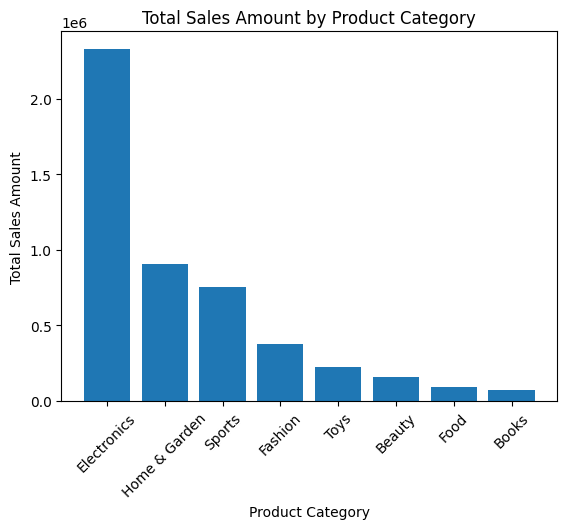

In [155]:
plt.bar(category_sales.index, category_sales.values)
plt.title("Total Sales Amount by Product Category")
plt.xlabel("Product Category")  
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

Electronics kategorisinin diğer kategorilere göre açık ara en yüksek satış tutarına sahip olduğu görülmektedir. Books kategorisinin de en düşük satış tutarına sahip olduğu görülmektedir.

### 6.2 Total Sales by City

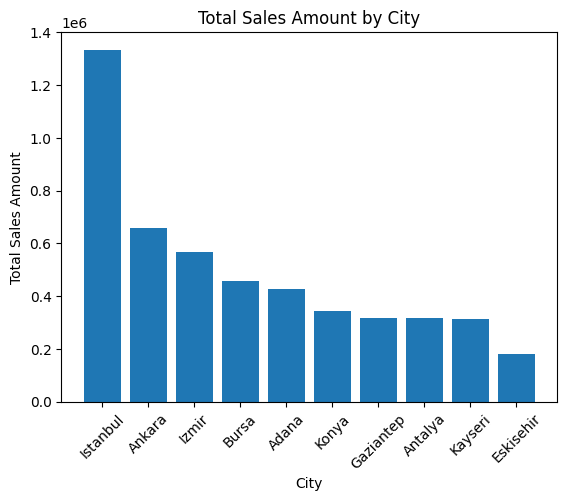

In [156]:
plt.bar(city_sales.index, city_sales.values)
plt.title("Total Sales Amount by City")
plt.xlabel("City")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


İstanbul en yüksek, Eskişehir ise en düşük toplam satış tutarına sahiptir.

### 6.3 Avarage Order Amount: New vs Returning Customers

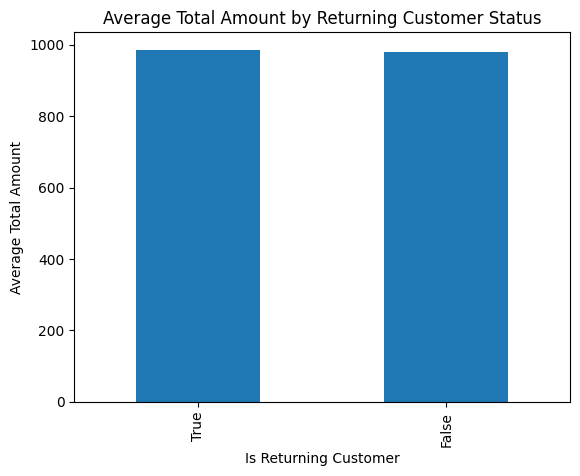

In [157]:
df.groupby("Is_Returning_Customer")["Total_Amount"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Total Amount by Returning Customer Status")
plt.xlabel("Is Returning Customer")
plt.ylabel("Average Total Amount")  
plt.show()

Geri dönen müşterilerin ortalama sipariş tutarı yeni müşterilere göre biraz daha yüksek olsa da aradaki fark oldukça küçüktür.

### 6.4 Discount Amount vs Total Amount

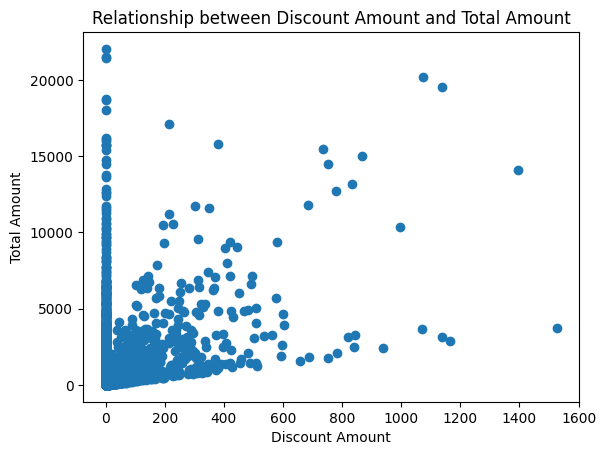

In [158]:
plt.scatter(df["Discount_Amount"], df["Total_Amount"])
plt.title("Relationship between Discount Amount and Total Amount")
plt.xlabel("Discount Amount")
plt.ylabel("Total Amount")
plt.show()

İndirim miktarı ile toplam satış tutarı arasında pozitif yönlü ancak güçlü olmayan bir ilişki görülmektedir. İndirim miktarı arttıkça toplam satış tutarında genel olarak bir artış eğilimi görülse de noktaların dağınık olması ilişkinin güçlü olmadığını göstermektedir.

### 6.5 Monthly Sales

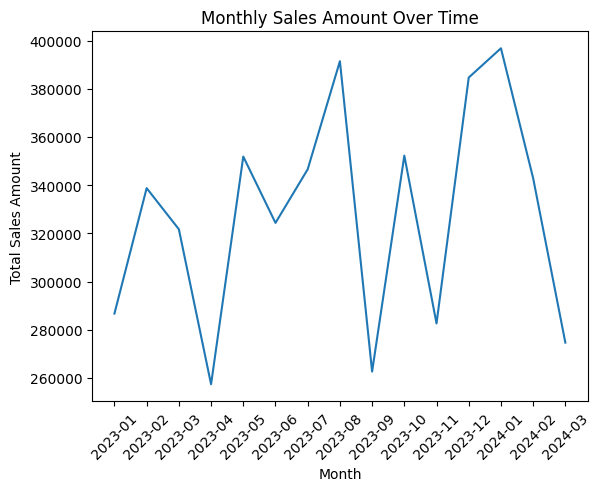

In [159]:
plt.plot(monthly_sales.index.astype(str), monthly_sales.values)
plt.title("Monthly Sales Amount Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)  
plt.show()

Aylık satışların genel olarak inişli çıkışlı bir yol izlediği, Ocak 2024 ve Ağustos 2023 dönemlerinde yüksek, Nisan 2023 döneminde ise düşük olduğu görülmektedir.

### 6.6 Avarage Order Amount by Device Type

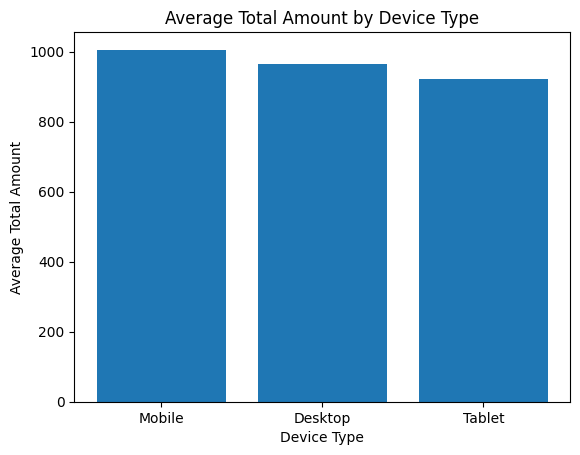

In [160]:
plt.bar(device_sales.index, device_sales.values)
plt.title("Average Total Amount by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Average Total Amount")
plt.show()

Mobile cihazlarda ortalama sipariş tutarı en yüksek, Tablet cihazlarda ise en düşüktür. Desktop ise bu iki kategori arasında yer almaktadır.

## 7. Key Findings

- Electronics kategorisi, toplam satış ve ortalama sipariş tutarında diğer kategorilerin önünde yer almaktadır.
- İstanbul, en yüksek toplam satış tutarına ve en yüksek sipariş sayısına sahip şehirdir.
- Geri dönen müşterilerin sayısı daha fazla olsa da yeni ve geri dönen müşterilerin ortalama sipariş tutarları arasında belirgin bir fark bulunmamaktadır.
- İndirim miktarı ile toplam satış tutarı arasında pozitif ancak güçlü olmayan bir ilişki bulunmaktadır.
- Aylık satışlar düzenli bir artış veya azalış yerine inişli çıkışlı bir seyir göstermektedir.
- Mobile cihazlarda ortalama sipariş tutarı en yüksekken Tablet cihazlarda en düşüktür.


## 8. Conclusion

Bu projede e-ticaret veri seti kullanılarak müşteri davranışları ve satışlar farklı değişkenlere göre incelenmiştir. Analiz sonucunda ürün kategorisi, şehir, müşteri durumu, indirim, zaman ve cihaz türü gibi değişkenlerin satışlarla olan ilişkileri değerlendirilmiştir. Elde edilen sonuçlar, satışların özellikle ürün kategorisi ve satış miktarına göre farklılık gösterdiğini ortaya koymuştur. Veri analizi ve görselleştirme yöntemleri kullanılarak verilerden anlamlı sonuçlar çıkarılmıştır.